# imports

In [1]:
import os, sys, json, datetime, re  # Provides OS-dependent functionality, system-specific parameters, JSON handling, and date/time manipulation
import pandas as pd             # Provides data structures and data analysis tools
import numpy as np              # Supports large, multi-dimensional arrays and matrices
import requests
import time
from tqdm import tqdm
import glob as glob

#thi data contants
from cprl_functions.defined_functions import *
from cprl_functions.state_capture import *
from cprl_functions.text_printing import bordered
from cprl_functions.data_packet_defs import *

#Import Data
###################
import data_sources.data_collection.pull_data as data_pull
from graphs.viz_graphs_template import *


# Create folder if needed
graphs_dir = r"C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Institute Team Site - Documents\Policy Team\Data Packets\K-12\graphs"

import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [r"C:\Users\clutz\Projects\fonts"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)



# merge file

In [ ]:
file = r"C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Institute Team Site - Documents\Policy Team\Data\Data Packets\K-12\merge_files\merge.csv"
df = pd.read_csv(file)
print(df.to_string(max_colwidth=30))

# graphs

In [4]:
from pathlib import Path

graphs_dir_path = Path(r'C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Institute Team Site - Documents\Policy Team\Data\Data Packets\K-12\graphs')

# Iterate through all subdirectories (state folders)
dir_paths = []
for state_dir in sorted(graphs_dir_path.iterdir()):
    if state_dir.name not in state_abbreviations_priority:
        continue
    if state_dir.is_dir():
        state_code = state_dir.name
        
        # Use pathlib instead of glob
        files = [str(f) for f in state_dir.iterdir() if f.is_file()]
        print(len(files))
        if len(files)<20:
            continue
        df = pd.DataFrame({'state': [state_code]*len(files), 'path': files})
        dir_paths.append(df)

df = pd.concat(dir_paths).reset_index(drop=True)

print(df.to_string())

36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
36
     state                                                                                                                             path
0       AZ  C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Institute Team Site - Documents\Policy Team\Data\Data Packets\K-12\graphs\AZ\1.1.png
1       AZ  C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Institute Team Site - Documents\Policy Team\Data\Data Packets\K-12\graphs\AZ\1.2.png
2       AZ  C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Institute Team Site - Documents\Policy Team\Data\Data Packets\K-12\graphs\AZ\1.3.png
3       AZ  C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Institute Team Site - Documents\Policy Team\Data\Data Packets\K-12\graphs\AZ\1.4.png
4       AZ  C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Institute Team Site - Documents\Policy Team\Data\Data Packets\K-12\graphs\AZ\2.1.png
5       AZ  C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Ins

In [5]:
graphs_ref = ['1.1.png', '1.2.png', '1.3.png', '1.4.png', '2.1.png', '2.2.png', '3.1.png', '3.2.png', '3.3.png', '3.4.png', '4.1.png', '4.2.png', '4.3.png', '4.4.png', '4.5.png', '4.6.png', '5.1.png', '5.2.png', '5.3.png', '5.4.png', '5.5.png', '5.6.png', '5.7.png', '5.8.png', '6.1.png', '6.2.png', '6.3.png', '7.1.png', '7.2.png', '7.3.png', '8.1.png', '8.2.png', '8.3.png', '8.4.png', '8.5.png', '9.1.png']

for state in state_abbreviations_priority:
    if 'US' in state:
        continue
    state_df = df[df['state']==state].reset_index()
    # print(len(state_df))
    graphs = [x.split('\\')[-1] for x in state_df['path']]
    print(bordered(state))
    # print(*graphs, sep='\n')
    for g in graphs_ref:
        if g not in graphs:
            print(f'missing graph {g} for {state}')

        
    # break





┌──┐
│AZ│
└──┘
┌──┐
│CT│
└──┘
┌──┐
│DC│
└──┘
┌──┐
│DE│
└──┘
┌──┐
│GA│
└──┘
┌──┐
│ID│
└──┘
┌──┐
│IL│
└──┘
┌──┐
│IN│
└──┘
┌──┐
│IA│
└──┘
┌──┐
│KS│
└──┘
┌──┐
│KY│
└──┘
┌──┐
│MD│
└──┘
┌──┐
│MA│
└──┘
┌──┐
│MI│
└──┘
┌──┐
│MN│
└──┘
┌──┐
│MO│
└──┘
┌──┐
│NE│
└──┘
┌──┐
│NJ│
└──┘
┌──┐
│NM│
└──┘
┌──┐
│NY│
└──┘
┌──┐
│NC│
└──┘
┌──┐
│ND│
└──┘
┌──┐
│OH│
└──┘
┌──┐
│OK│
└──┘
┌──┐
│OR│
└──┘
┌──┐
│RI│
└──┘
┌──┐
│SC│
└──┘
┌──┐
│TN│
└──┘
┌──┐
│TX│
└──┘
┌──┐
│VT│
└──┘
┌──┐
│VA│
└──┘
┌──┐
│WA│
└──┘
┌──┐
│WV│
└──┘
┌──┐
│WY│
└──┘


In [3]:
# get image dimensions
import re, os
from PIL import Image
from pathlib import Path

def get_image_dimensions(folder_path):
    """
    Get dimensions of all images in a folder.
    
    Args:
        folder_path: Path to folder containing images
        
    Returns:
        Dictionary mapping filename to (width, height) tuple
    """
    folder = Path(folder_path)
    dimensions = {}
    
    # Common image extensions
    image_extensions = {'.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp'}
    
    # Iterate through all files in folder
    for img_path in folder.iterdir():
        if img_path.is_file() and img_path.suffix.lower() in image_extensions:
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    filename = img_path.stem  # Gets "AZ1.1" from "AZ1.1.png"
                    graph_match = re.search(r'^\d\.\d', str(filename))
                    graph_num = graph_match.group(0)
                    # print(graph_num)
                    dimensions[graph_num] = (width, height)
            except Exception as e:
                print(f"Error reading {img_path.name}: {e}")
    
    return dimensions

# Usage

folder_path = r'C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Institute Team Site - Documents\Policy Team\Data\Data Packets\K-12\graphs\AZ'
# folder_path = r'C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Institute Team Site - Documents\K-12 Team\10_Hunt Kean Fellows\C11S1\State Graphics\Arizona'
# folder_path = r'C:\Users\clutz\Downloads\k12 datapackets\AZ'
dims = get_image_dimensions(folder_path)

# Print results
for filename, (width, height) in dims.items():
    print(f"{filename}: ({width}, {height})")

1.1: (855, 755)
1.2: (2525, 455)
1.3: (2525, 455)
1.4: (2525, 455)
2.1: (1260, 1000)
2.2: (1260, 1000)
3.1: (1260, 720)
3.2: (1260, 720)
3.3: (1260, 720)
3.4: (1260, 720)
4.1: (665, 560)
4.2: (665, 560)
4.3: (665, 560)
4.4: (665, 560)
4.5: (1260, 540)
4.6: (1260, 540)
5.1: (1300, 560)
5.2: (1300, 560)
5.3: (1300, 560)
5.4: (1300, 560)
5.5: (1300, 560)
5.6: (1300, 560)
5.7: (1300, 560)
5.8: (1300, 560)
6.1: (2450, 600)
6.2: (1300, 500)
6.3: (2425, 550)
7.1: (2520, 650)
7.2: (2520, 650)
7.3: (2520, 650)
8.1: (2525, 475)
8.2: (2700, 725)
8.3: (825, 470)
8.4: (825, 470)
8.5: (825, 470)
9.1: (2550, 500)


In [ ]:
from PIL import Image
from pathlib import Path

def get_graph_dimensions(folder_path):
    folder = Path(folder_path)
    dimensions = {}
    
    for img_path in sorted(folder.iterdir()):
        # print(img_path)
        if img_path.suffix.lower() == '.png':
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    print(img.size)
                    # Extract graph number (e.g., "1.1" from "AZ1.1.png")
                    # Remove state code and extension
                    filename = img_path.stem  # Gets "AZ1.1" from "AZ1.1.png"
                    graph_match = re.search(r'^\d\.\d')
                    graph_num = graph_match.group(0)
                    print(graph_num)
                    # graph_num = filename[2:]  # Removes "AZ" to get "1.1"
                    dimensions[graph_num] = (width, height)
            except Exception as e:
                print(f"Error: {e}")
    
    return dimensions

# Usage
folder_path = r'C:\Users\clutz\THE HUNT INSTITUTE\The Hunt Institute Team Site - Documents\K-12 Team\10_Hunt Kean Fellows\C11S1\State Graphics\Arizona'
dims = get_graph_dimensions(folder_path)

# Print formatted output
print("sizing = {")
for graph_num, (width, height) in sorted(dims.items()):
    print(f"    '{graph_num}': ({width}, {height}),")
print("}")

In [ ]:
# sizing diff
sizing = {
    '1.1':(1102,915),
    '1.2':(2327,419),
    '1.3':(2327,419),
    '1.4':(2327,419),
    '2':(1352,768),
    '3':(1340,768),
    '4':(668,621),
    '4.5':(1340,575),
    '4.6':(1340,575),
    '5':(1142,541),
    '6.1':(2703,628),
    '6.2':(1355,588),
    '6.3':(2828,648),
    '7.1':(3375,691),
    '7.2':(2700,728),
    '7.3':(2704,651),
    '8.1':(4036,763),
    '8.2':(2482,660),
    '8.3':(901,499),
    '8.4':(945,500),
    '8.5':(1471,500),
    '9.1':(2482,660),
}
def get_sizing(graph_num):
    # Convert to string if not already
    graph_num_str = str(graph_num)
    
    # Check if exact match exists in sizing dict
    if graph_num_str in sizing:
        return sizing[graph_num_str]
     
    # Check for 2.x pattern
    two_match = re.search(r'^2\.(\d)', graph_num_str)
    if two_match is not None:
        
        return sizing.get('2')
        
    
    # Check for 3.x pattern
    tres_match = re.search(r'^3\.(\d)', graph_num_str)
    if tres_match is not None:
        
        return sizing.get('3')
    
    
    # Check for 4.x pattern
    four_match = re.search(r'^4\.(\d)', graph_num_str)
    if four_match is not None:
        if int(four_match.group(1)) < 5:
            return sizing.get('4')
        else:
            return sizing.get('4.5')  # Default for 4.5+
    
    # Check for 5.x pattern
    five_match = re.search(r'^5\.', graph_num_str)
    if five_match is not None:
        return sizing.get('5')
    
    # Default fallback - return a default size or None
    print(f"Warning: No sizing found for graph {graph_num_str}")
    return (1000, 600)  # Default size or use None if you want to filter these out


In [ ]:

import cv2

# Read the image
img = cv2.imread('example.jpg')

# Display the image
cv2.imshow('Image Window', img)

# Wait for key press to close
cv2.waitKey(0)
cv2.destroyAllWindows()




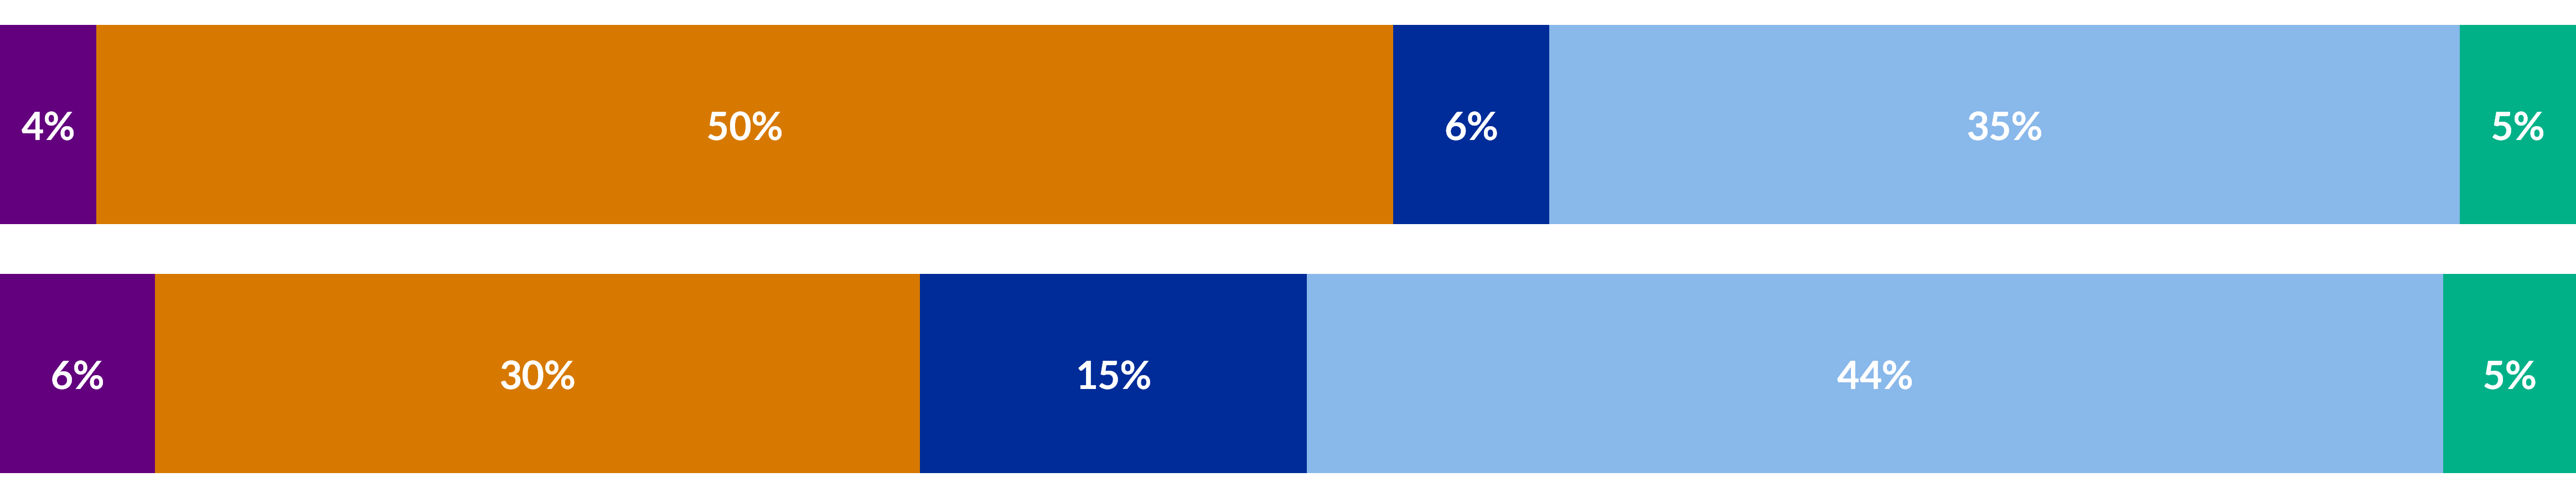

KeyboardInterrupt: 

In [25]:

import ipyplot
from PIL import Image
from IPython.display import clear_output
import cv2

from time import sleep
df = df[df['state']=='AZ']
from IPython.display import HTML
from PIL import Image
import base64
from io import BytesIO

def display_resized(img, width=800):
    # Convert image to base64
    buffered = BytesIO()
    img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode()
    return HTML(f"<img src='data:image/png;base64,{img_str}' width='{width}px'>")

for image_path in df['path']:

    # Example usage
    with Image.open(image_path) as img:
        display(display_resized(img, width=300))
        time.sleep(4)
        clear_output()


In [ ]:

# df['width'],df['height'] = zip(*df['path'].str.split('\\').str[-1].str.replace('.png', '').apply(lambda x: get_sizing(x)))

# print(df.to_string())
# images = [Image.open(path) for path in df['path']]
# ipyplot.plot_images(images,img_width=df['width'])

# from IPython.display import Image, display
import time
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Read the image


# # Display the image
# plt.imshow(img)
# plt.axis('off')  # Hide axes
# plt.show()

from IPython.display import display, clear_output
import time
from PIL import Image

for image_path in df['path']:
    with Image.open(image_path) as img:
        display(img)
        time.sleep(3)
        clear_output(wait=True)



In [ ]:

import ipyplot
from PIL import Image
df = df[df['state']=='AZ']
df['width'],df['height'] = zip(*df['path'].str.split('\\').str[-1].str.replace('.png', '').apply(lambda x: get_sizing(x)))

# print(df.to_string())
images = [Image.open(path) for path in df['path']]
ipyplot.plot_images(images,img_width=df['width'])



In [ ]:


# ipyplot.plot_class_tabs(images, labels, max_imgs_per_tab=10, img_width=150)
        
        # # Check which graphs exist for this state
        # for graph_file, column_tag in GRAPH_MAPPINGS.items():
        #     graph_path = state_dir / graph_file
        #     if graph_path.exists():
        #         # Store relative path from main directory
        #         state_mappings[state_code][column_tag] = str(graph_path.resolve())

# print(state_mappings)

In [ ]:
# set up

def read_pdf_line_by_line(sat_files):
    # all_lines = kwargs.get('all_lines', False)
    # Open the PDF file for reading
    lines_by_state = {}
    for file_item in glob.glob(os.path.join(sat_files,'*')):
        #open file
        with open(file_item, 'rb') as file:
            filename = file.name.split('\\')[-1].replace('-',' ')
            
            #get state abbreviation
            for state in state_list_lower:
                if state in filename:
                    state_abrv = state_ref_lower.get(state)
            # filter pages
            reader = PyPDF2.PdfReader(file)
            pages_to_read = [3, 4]  # Pages 3 and 4 (0-indexed)
            lines_list = []
            
            #get lines from pages
            for i in pages_to_read:
                if i < 0 or i >= len(reader.pages):
                    continue
                page = reader.pages[i]
                text = page.extract_text()
                if not text:
                    continue
                lines = text.splitlines()
                lines_list.append(lines)
            
            # Flatten and clean lines - remove excessive whitespace
            all_lines = list(itertools.chain.from_iterable(lines_list))
            # Strip whitespace and remove empty lines
            all_lines = [line.strip().replace('\t',' ') for line in all_lines if line.strip()]
        lines_by_state[state_abrv] = all_lines
    return lines_by_state
lines_by_state = read_pdf_line_by_line(sat_files)

In [ ]:
#percent participating
participation_dfs = []
for state,lines in lines_by_state.items():
    start_line = None
    break_line = None
    # print('_______________________')
    # print(bordered(state))
    for i,line in enumerate(lines):
        line_str = re.sub(r'\s{2,}',' ', str(line))
        if 'Class of 2025' in line_str and start_line is None:
            start_line = i
            continue

        if 'Class of 2026' in line_str:
            # print(line)
            break_line = i+1
            break
    new_lines = lines[start_line:break_line]
    # print(*new_lines, sep='\n')
    for nline in new_lines:
        line_str = re.sub(r'\s{2,}',' ', str(nline))
        # print(line_str)

        if re.search(r'SAT\s[Pp]articipation', line_str):
            # print('this one')
            value = re.search(r'\d{1,3}%',nline)
            if value is None:
                continue
            else:
                percent = value.group(0)
                # print(percent)
                df = pd.DataFrame({'state':[state], 'participation': [percent]})
                participation_dfs.append(df)
                # print(nline)
                break
participation_df = pd.concat(participation_dfs).reset_index(drop=True)
# print(participation_df.to_string())


In [ ]:
#avg score
lines_avg = {}
values = []
for state,lines in lines_by_state.items():
    #debugging lines
    #############
    # if state != 'KS':
    #     continue
    # print(bordered(state))
    
    
    #get the right section
    #############
    start_line = None
    break_line = None
    for i,line in enumerate(lines):
        
        need = ['Test','Takers','Mean']
        exclude = []
        if all(str(x) in str(line) for x in need) and not any(str(x) in str(line) for x in exclude) and start_line is None:
            start_line = i
            continue
        elif 'race' in str(line).lower():
            print(line)
            break_line = i
            break

    avg_lines = lines[start_line:break_line]
    
    # print(*avg_lines, sep = '\n')


    #match for actual value out of those results
    #############    
    matched = False
    for aline in avg_lines:
        if matched == True:
            break
        #get row vals
        split_by_space = aline.split(' ')
        split_by_space = [x for x in split_by_space if len(x) > 0]    
        

        #if none can be a digit, its not the right row
        if any(x.isdigit() for x in split_by_space) and matched == False:

            #go through the values
            for sp in split_by_space:
                
                #check for match
                match = re.search(r'^0?\d{3,4}$',sp.replace(',','').strip())
                if match is not None and int(match.group(0))<=2000 and int(match.group(0))>600:
                    print(match.group(0))
                    value = int(match.group(0))

                    #export it and go to next state
                    df = pd.DataFrame({'state': [state], 'avg_score': [value]})
                    values.append(df)
                    matched = True
                    break
        
        

avg_vals = pd.concat(values).sort_values('avg_score', ascending=False).reset_index(drop=True)
print(avg_vals.to_string())


In [ ]:


new_one = participation_df.merge(avg_vals, on = 'state', how= 'inner')
new_one.to_clipboard()
# all_sat_data = 
print(new_one.to_string())
# %%
